<a href="https://colab.research.google.com/github/ayushi777lodhi-stack/Vision-MultiModal-Learning/blob/main/autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
BATCH_SIZE=128
data_transform=transforms.Compose([transforms.ToTensor()])

train_dataset=datasets.MNIST(root="./data", train=True, transform =data_transform, download=True)
train_loader=DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class AutoEncoder(nn.Module):
  def __init__(self, latent_dim=32, hidden_dim=256):
    super().__init__()

    self.encoder=nn.Sequential(
        nn.Linear(784,hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim,latent_dim),
        nn.ReLU()
    )

    self.decoder=nn.Sequential(
        nn.Linear(latent_dim,hidden_dim),
        nn.ReLU(),
        nn.Linear(256,784),
        nn.Sigmoid()
    )



  def forward(self,x):
    z=self.encoder(x)
    x_recon=self.decoder(z)

    return x_recon


In [ ]:
model=AutoEncoder().to(device)
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=1e-3)

In [ ]:
epochs=20
model.train()
for epoch in range(epochs):
  total_loss=0
  for x, _ in train_loader:
    x=x.view(-1,784).to(device)
    optimizer.zero_grad()
    x_recon=model(x)
    loss=criterion(x_recon,x)
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()

  avg_loss=total_loss/len(train_loader)
  print(f"epoch:{epoch+1/epochs},loss:{avg_loss:.6f}")


epoch:0.05,loss:0.012138
epoch:1.05,loss:0.011623
epoch:2.05,loss:0.011215
epoch:3.05,loss:0.010867
epoch:4.05,loss:0.010573
epoch:5.05,loss:0.010311
epoch:6.05,loss:0.010093
epoch:7.05,loss:0.009894
epoch:8.05,loss:0.009725
epoch:9.05,loss:0.009556
epoch:10.05,loss:0.009429
epoch:11.05,loss:0.009293
epoch:12.05,loss:0.009174
epoch:13.05,loss:0.009064
epoch:14.05,loss:0.008967
epoch:15.05,loss:0.008871
epoch:16.05,loss:0.008787
epoch:17.05,loss:0.008707
epoch:18.05,loss:0.008636
epoch:19.05,loss:0.008582


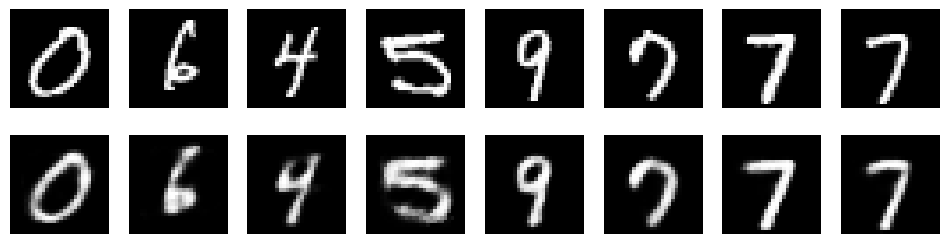

In [ ]:
model.eval()
with torch.no_grad():
  x,_=next(iter(train_loader))
  x=x.view(-1,784).to(device)

  x_recon=model(x)
  n=8
  plt.figure(figsize=(12,3))

  for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x[i].view(28,28).cpu(), cmap="gray")
    plt.axis("off")

    plt.subplot(2,n,n+i+1)
    plt.imshow(x_recon[i].view(28,28).cpu(), cmap="gray")
    plt.axis("off")


  plt.show()


In [ ]:
# model.eval()

# latents=[]
# labels=[]

# with torch.no_grad():
#   for x, y in train_loader:
#     x=x.view(-1,784).to(device)
#     z=model.encoder(x)

#     latents.append(z.cpu())
#     labels.append(y)

# latents=torch.cat(latents, dim=0)
# labels=torch.cat(labels, dim=0)

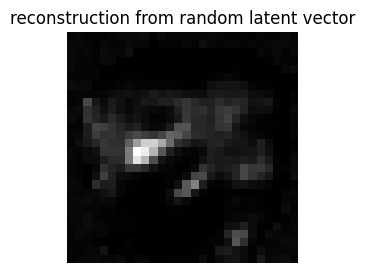

In [ ]:
model.eval()

with torch.no_grad():
  latent_dim=model.encoder[-2].out_features
  z_random=torch.randn(1,latent_dim).to(device)

  x_generated=model.decoder(z_random)
  x_generated=x_generated.cpu().view(28,28)


plt.figure(figsize=(3,3))
plt.imshow(x_generated, cmap="gray")
plt.axis("off")
plt.title("reconstruction from random latent vector")
plt.show()
